# Notebook 9 - Categorical Data Analysis

Dataset: `healthcare_dataset.csv`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('healthcare_dataset.csv')
df.shape

(55500, 15)

In [2]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

C:\Users\sibyr\AppData\Local\Temp\ipykernel_21688\3141574336.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


['Name',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results']

## 1. Unique Categories

Each categorical column is checked for the number of distinct values it contains.

In [3]:
unique_counts = df[cat_cols].nunique().sort_values(ascending=False)
unique_counts

Name                  49992
Doctor                40341
Hospital              39876
Discharge Date         1856
Date of Admission      1827
Blood Type                8
Medical Condition         6
Insurance Provider        5
Medication                5
Admission Type            3
Test Results              3
Gender                    2
dtype: int64

## 2. High Cardinality vs Low Cardinality

- **High cardinality**: a column with a very large number of unique values relative to the dataset size, often close to one value per record. Examples here: `Name`, `Doctor`, `Hospital`, `Date of Admission`, `Discharge Date`.
- **Low cardinality**: a column with a small, fixed set of possible values. Examples here: `Gender`, `Blood Type`, `Medical Condition`, `Insurance Provider`, `Admission Type`, `Medication`, `Test Results`.

High-cardinality columns like `Name`, `Doctor`, and `Hospital` behave more like identifiers than informative categories for modeling and are generally excluded from category-frequency analysis, though `Doctor` and `Hospital` can still be useful for aggregation (e.g. counting cases per doctor).

In [4]:
cardinality_ratio = (unique_counts / len(df)).round(4)
cardinality_summary = pd.DataFrame({
    'unique_values': unique_counts,
    'cardinality_ratio': cardinality_ratio
})
cardinality_summary['cardinality_type'] = cardinality_summary['cardinality_ratio'].apply(
    lambda x: 'High' if x > 0.05 else 'Low'
)
cardinality_summary

,unique_values,cardinality_ratio,cardinality_type
Name,49992,0.9008,High
Doctor,40341,0.7269,High
Hospital,39876,0.7185,High
Discharge Date,1856,0.0334,Low
Date of Admission,1827,0.0329,Low
Blood Type,8,0.0001,Low
Medical Condition,6,0.0001,Low
Insurance Provider,5,0.0001,Low
Medication,5,0.0001,Low
Admission Type,3,0.0001,Low


## 3. Low-Cardinality Categorical Features

The remaining analysis focuses on the low-cardinality, informative categorical variables.

In [5]:
low_card_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
for col in low_card_cols:
    print(f"{col}: {df[col].nunique()} categories")

Gender: 2 categories
Blood Type: 8 categories
Medical Condition: 6 categories
Insurance Provider: 5 categories
Admission Type: 3 categories
Medication: 5 categories
Test Results: 3 categories


## 4. Category Frequencies

In [6]:
for col in low_card_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
Male      27774
Female    27726
Name: count, dtype: int64

--- Blood Type ---
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

--- Medical Condition ---
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

--- Insurance Provider ---
Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

--- Admission Type ---
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

--- Medication ---
Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

--- Test Results ---
Test Results
Abnormal        18627
Normal          18517
Inco

## 5. Category Distribution (Visualized)

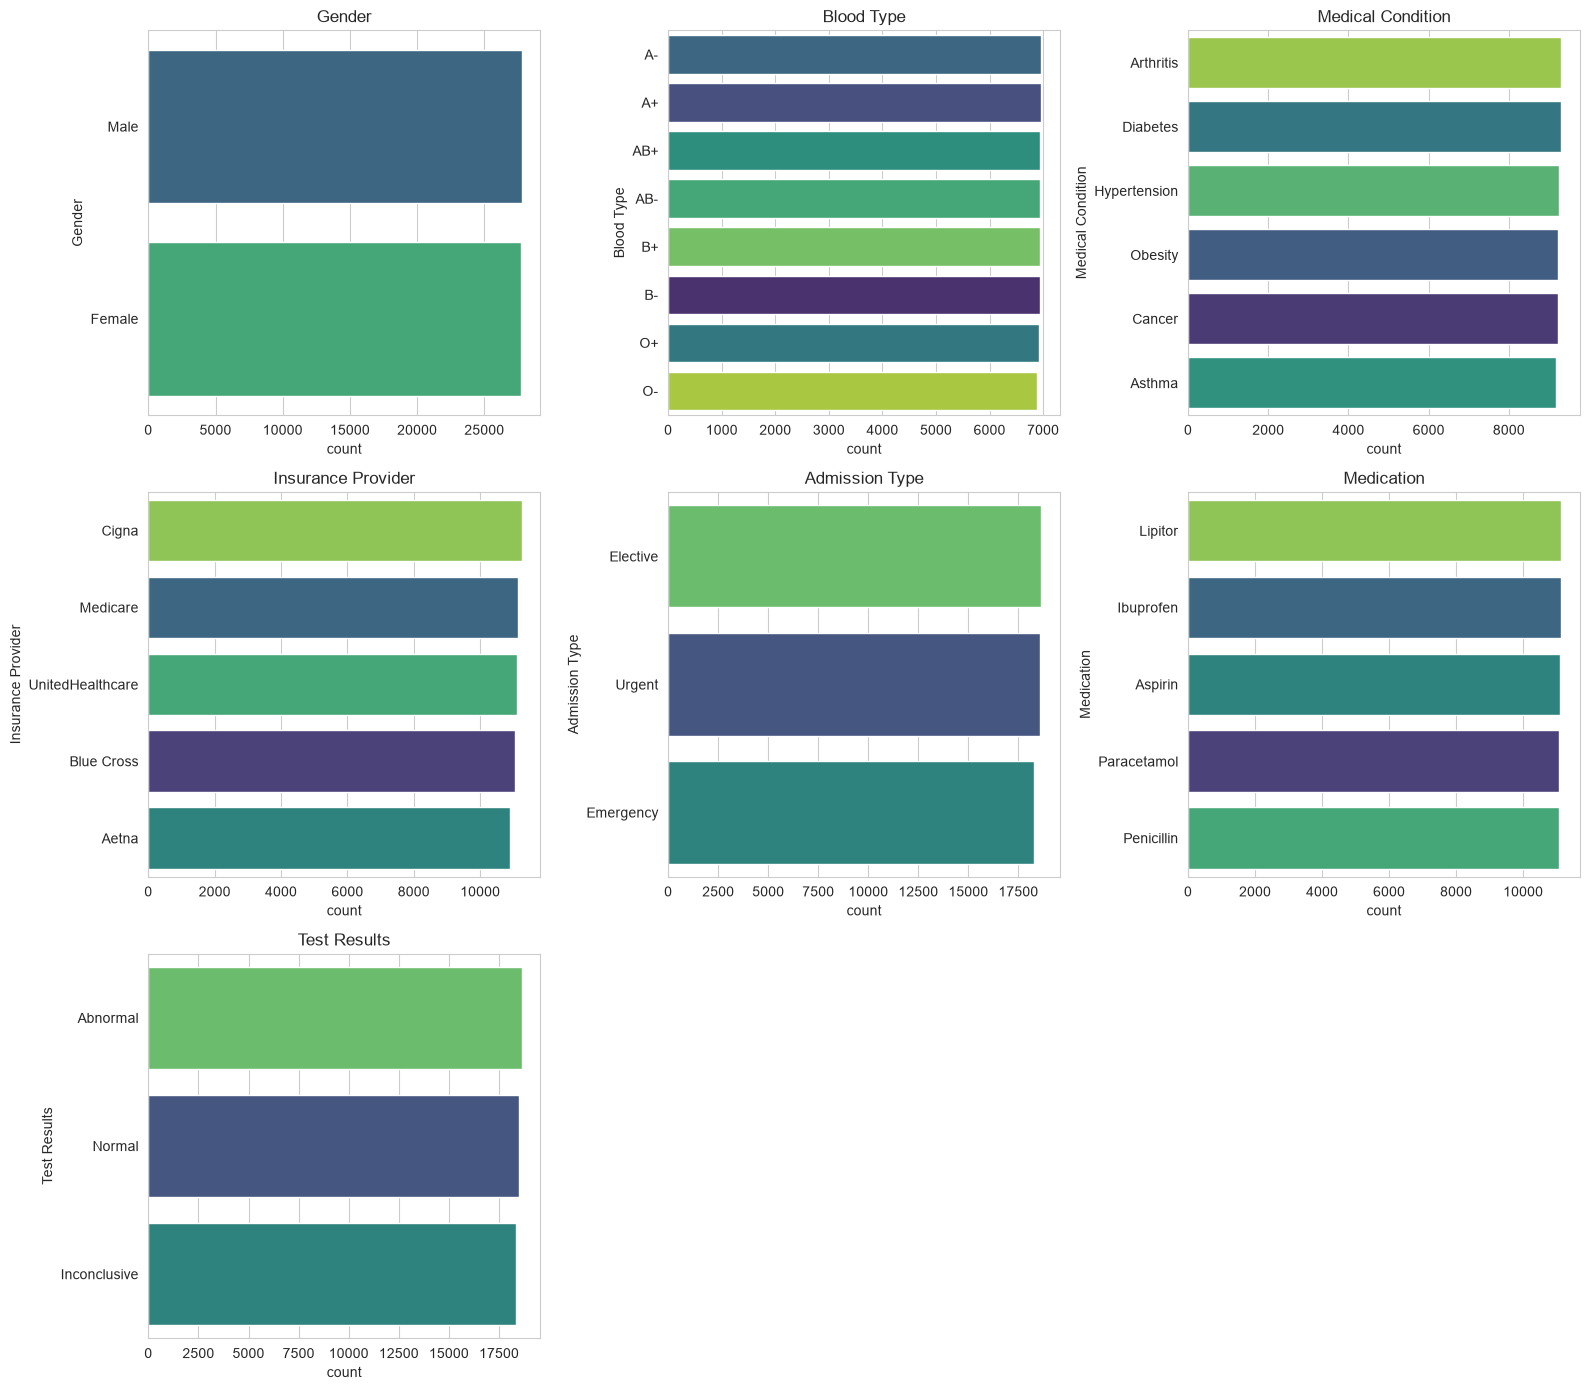

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(low_card_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(col)
for j in range(len(low_card_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Observations:**

- `Gender` splits close to evenly between the two categories.
- `Blood Type` has 8 categories that appear close to evenly distributed, with no single blood type dominating.
- `Medical Condition` has 6 categories (Cancer, Obesity, Diabetes, Asthma, Hypertension, Arthritis) that appear roughly balanced.
- `Insurance Provider` has 5 categories with a relatively even split.
- `Admission Type` has 3 categories (Emergency, Elective, Urgent) that appear roughly balanced.
- `Medication` has 5 categories that appear roughly balanced.
- `Test Results` (the target variable) has 3 categories (Normal, Abnormal, Inconclusive).

## 6. Category Imbalance Check

Category imbalance occurs when one or more categories dominate a feature, which can bias models trained on the data. The ratio between the most frequent and least frequent category quantifies this.

In [8]:
imbalance_summary = {}
for col in low_card_cols:
    counts = df[col].value_counts()
    imbalance_summary[col] = {
        'most_frequent': counts.index[0],
        'most_frequent_pct': round(counts.iloc[0] / len(df) * 100, 2),
        'least_frequent': counts.index[-1],
        'least_frequent_pct': round(counts.iloc[-1] / len(df) * 100, 2),
        'imbalance_ratio': round(counts.iloc[0] / counts.iloc[-1], 3)
    }
pd.DataFrame(imbalance_summary).T

,most_frequent,most_frequent_pct,least_frequent,least_frequent_pct,imbalance_ratio
Gender,Male,50.04,Female,49.96,1.002
Blood Type,A-,12.56,O-,12.39,1.013
Medical Condition,Arthritis,16.77,Asthma,16.55,1.013
Insurance Provider,Cigna,20.27,Aetna,19.66,1.031
Admission Type,Elective,33.61,Emergency,32.92,1.021
Medication,Lipitor,20.07,Penicillin,19.94,1.007
Test Results,Abnormal,33.56,Inconclusive,33.07,1.015


**Interpretation:** an imbalance ratio close to 1 indicates a near-even split across categories. All low-cardinality features here show ratios close to 1, meaning this dataset does not suffer from severe class imbalance in its categorical features, including the target variable `Test Results`. This is a synthetically generated dataset, which explains the unusually even distribution across categories; real-world healthcare data would typically show more skew (e.g. Emergency admissions often outnumber Elective ones).

## 7. Rare Categories

A rare category is typically defined as one making up less than some small threshold (e.g. 1%) of total records. Rare categories can cause instability in modeling since there is little data to learn from them.

In [9]:
rare_threshold = 0.01
rare_report = {}
for col in low_card_cols:
    freq = df[col].value_counts(normalize=True)
    rare_cats = freq[freq < rare_threshold]
    rare_report[col] = list(rare_cats.index)

rare_report

{'Gender': [],
 'Blood Type': [],
 'Medical Condition': [],
 'Insurance Provider': [],
 'Admission Type': [],
 'Medication': [],
 'Test Results': []}

No categories fall below the 1% threshold in any of the low-cardinality columns, confirming there are no rare categories requiring special handling (such as grouping into an "Other" bucket) in this dataset.

## 8. High-Cardinality Columns

`Doctor` and `Hospital` are examined separately since, despite being high cardinality, they may still carry useful aggregate signal (e.g. case volume per doctor).

In [10]:
doctor_counts = df['Doctor'].value_counts()
print(f"Total unique doctors: {df['Doctor'].nunique()}")
print(f"Doctors with only 1 record: {(doctor_counts == 1).sum()}")
doctor_counts.head(10)

Total unique doctors: 40341
Doctors with only 1 record: 30576


Doctor
Michael Smith       27
John Smith          22
Robert Smith        22
James Smith         20
Michael Johnson     20
Robert Johnson      19
David Smith         19
Michael Williams    18
Matthew Smith       17
John Johnson        17
Name: count, dtype: int64

In [11]:
hospital_counts = df['Hospital'].value_counts()
print(f"Total unique hospitals: {df['Hospital'].nunique()}")
print(f"Hospitals with only 1 record: {(hospital_counts == 1).sum()}")
hospital_counts.head(10)

Total unique hospitals: 39876
Hospitals with only 1 record: 31706


Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    38
Smith Ltd      37
Smith PLC      36
Smith Group    36
Johnson Inc    35
Smith Inc      34
Smith LLC      32
Group Smith    32
Name: count, dtype: int64

**Interpretation:** the vast majority of doctors and hospitals appear only once or a handful of times in the dataset. This confirms these columns behave as near-unique identifiers rather than meaningful groupings, and are not suitable for direct use as categorical features in a model without aggregation or removal.

## 9. Relationship with the Target Variable

`Test Results` (Normal, Abnormal, Inconclusive) is treated as the target variable. Each low-cardinality categorical feature is checked for association with it.

In [12]:
df['Test Results'].value_counts(normalize=True) * 100

Test Results
Abnormal        33.562162
Normal          33.363964
Inconclusive    33.073874
Name: proportion, dtype: float64

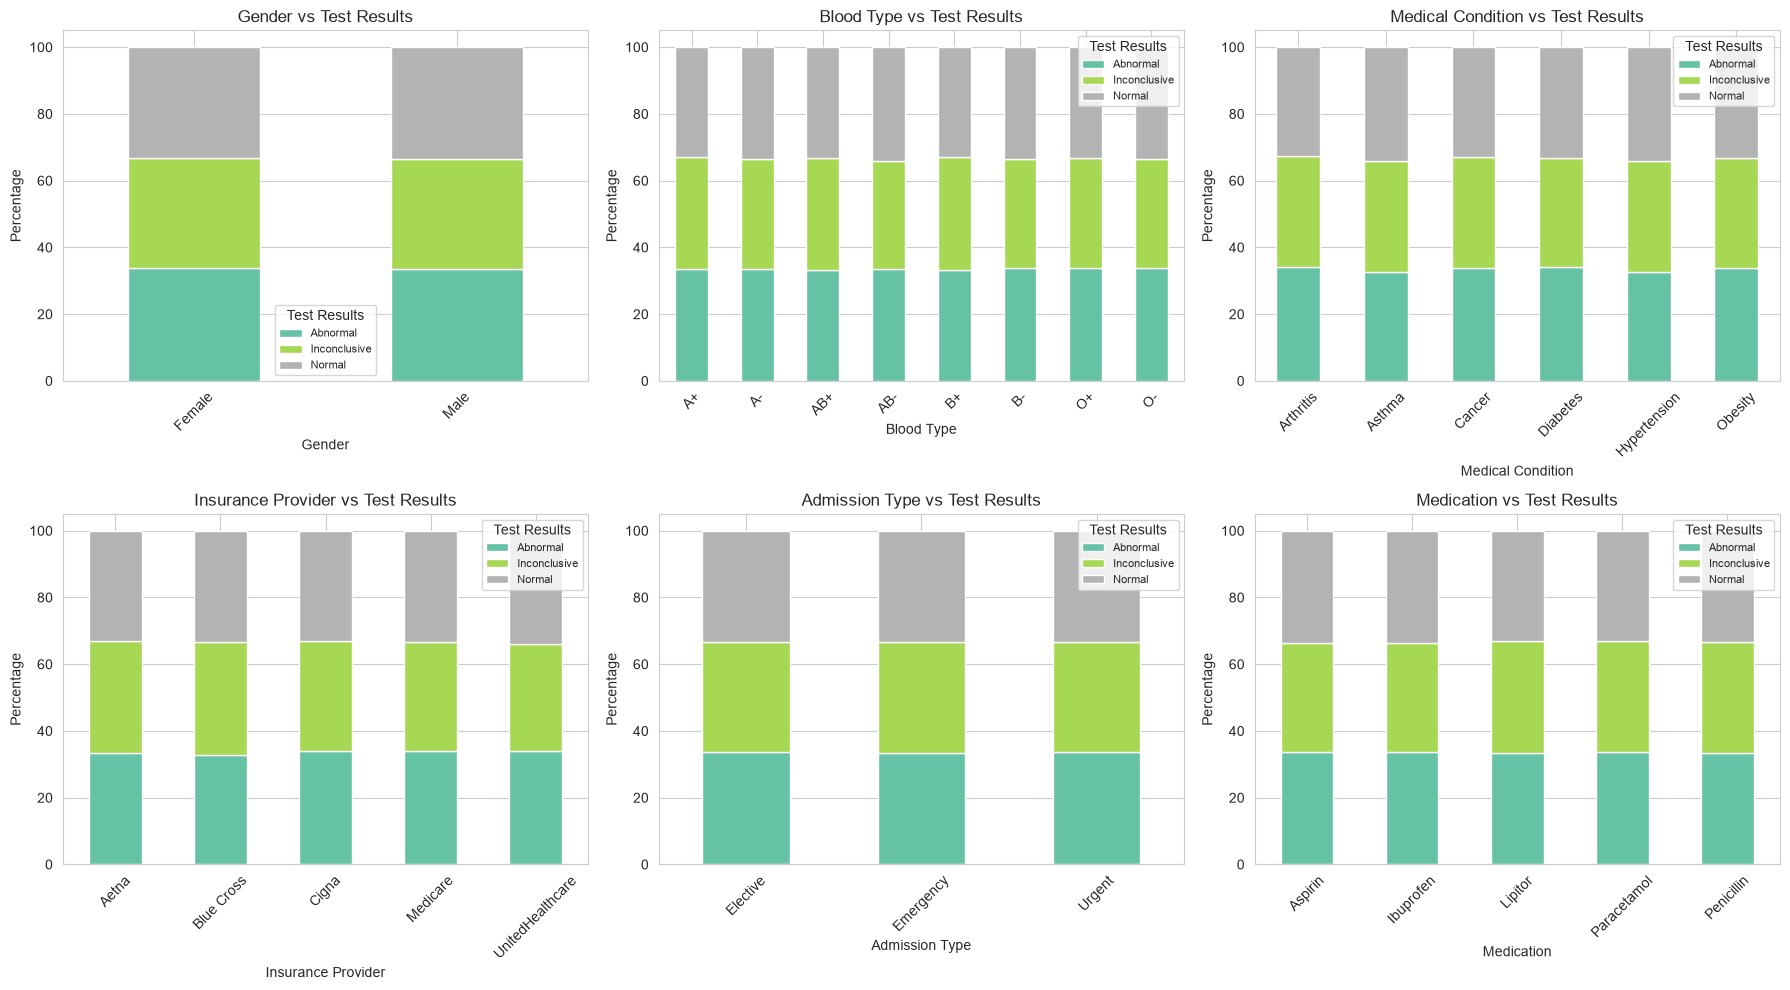

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
feature_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']
for i, col in enumerate(feature_cols):
    cross = pd.crosstab(df[col], df['Test Results'], normalize='index') * 100
    cross.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
    axes[i].set_title(f'{col} vs Test Results')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(title='Test Results', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 10. Statistical Association: Chi-Square Test

The Chi-Square test of independence checks whether a categorical feature is statistically associated with `Test Results`. A low p-value (below 0.05) would indicate a significant association.

In [14]:
chi_square_results = {}
for col in feature_cols:
    contingency = pd.crosstab(df[col], df['Test Results'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_square_results[col] = {
        'chi2_statistic': round(chi2, 3),
        'p_value': round(p, 4),
        'degrees_of_freedom': dof,
        'significant_at_0.05': p < 0.05
    }
pd.DataFrame(chi_square_results).T

,chi2_statistic,p_value,degrees_of_freedom,significant_at_0.05
Gender,2.018,0.3645,2,False
Blood Type,7.632,0.9076,14,False
Medical Condition,13.255,0.2098,10,False
Insurance Provider,8.378,0.3975,8,False
Admission Type,1.32,0.858,4,False
Medication,3.731,0.8805,8,False


**Interpretation:** p-values above 0.05 across these features indicate no statistically significant association with `Test Results` in this dataset. This is consistent with the synthetic, near-uniform nature of the data noted earlier. In a real clinical dataset, features such as `Medical Condition` or `Admission Type` would typically be expected to show a stronger relationship with test outcomes.

## 11. Medical Condition by Admission Type

As a secondary relationship check between two categorical variables (not involving the target), `Medical Condition` is cross-tabulated with `Admission Type` to look for any clustering pattern.

In [15]:
condition_admission = pd.crosstab(df['Medical Condition'], df['Admission Type'], normalize='index') * 100
condition_admission

Admission Type,Elective,Emergency,Urgent
Medical Condition,,,
Arthritis,33.122046,33.390632,33.487323
Asthma,33.772455,32.683723,33.543821
Cancer,34.117265,32.675843,33.206893
Diabetes,32.867584,32.426913,34.705503
Hypertension,34.840454,32.460790,32.698756
Obesity,32.965009,33.864153,33.170837


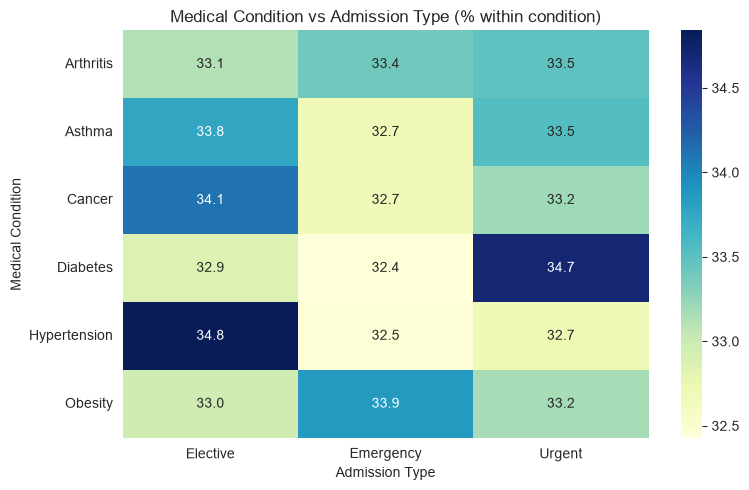

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(condition_admission, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Medical Condition vs Admission Type (% within condition)')
plt.tight_layout()
plt.show()

**Interpretation:** the percentage split of admission types within each medical condition is close to even across conditions, reinforcing the earlier finding that this dataset does not show the kind of category dependency typically expected in real clinical data.